<a href="https://colab.research.google.com/github/Mohotasir/python_practice/blob/main/DL_paper.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from sklearn.metrics import classification_report, accuracy_score, f1_score
import matplotlib.pyplot as plt
import numpy as np
import time
import copy

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
dataset_path = "/content/drive/MyDrive/PlantVillage"

In [ ]:
import os

for folder in os.listdir(dataset_path):
    print(folder)

PlantVillage
Tomato_Early_blight
Tomato_Late_blight
Tomato_Bacterial_spot
Tomato_healthy
Tomato_Leaf_Mold
Tomato_Spider_mites_Two_spotted_spider_mite
Tomato_Septoria_leaf_spot
Pepper_bell_Bacterial_spot
Pepper_bell_healthy
Potato_Early_blight
Potato_healthy
Potato_Late_blight
Tomato_Target_Spot
Tomato_Tomato_mosaic_virus
Tomato_Tomato_YellowLeaf_Curl_Virus


In [ ]:
sample_path = dataset_path + "/Tomato_Early_blight"

print(len(os.listdir(sample_path)))

1000


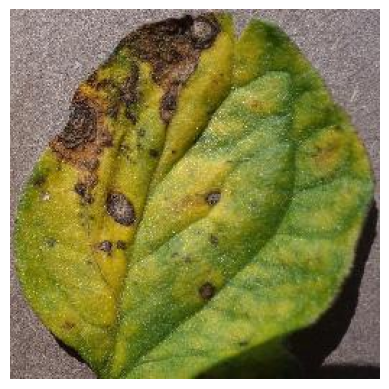

In [ ]:
import matplotlib.pyplot as plt
import cv2
import random

img_name = random.choice(os.listdir(sample_path))
img = cv2.imread(sample_path + "/" + img_name)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img)
plt.axis('off')
plt.show()

**USE only TOMATO leaf data**

In [ ]:
tomato_classes = sorted([folder for folder in os.listdir(dataset_path) if folder.startswith("Tomato")])

print("Tomato Classes:", tomato_classes)
print("Total Classes:", len(tomato_classes))

Tomato Classes: ['Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_Late_blight', 'Tomato_Leaf_Mold', 'Tomato_Septoria_leaf_spot', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato_Target_Spot', 'Tomato_Tomato_YellowLeaf_Curl_Virus', 'Tomato_Tomato_mosaic_virus', 'Tomato_healthy']
Total Classes: 10


In [ ]:
base_output = "/content/plantvillage_tomato"

splits = ["train", "val", "test"]

for s in splits:
    for c in tomato_classes:
        os.makedirs(os.path.join(base_output, s, c), exist_ok=True)

print("Folder structure created successfully!")

Folder structure created successfully!


#**DATASET spliting**

In [ ]:
import shutil
import random

random.seed(42)

for cls in tomato_classes:
    src_folder = os.path.join(dataset_path, cls)
    images = [img for img in os.listdir(src_folder) if img.lower().endswith(('.jpg', '.jpeg', '.png'))]

    random.shuffle(images)

    total = len(images)
    train_end = int(0.7 * total)
    val_end = int(0.85 * total)

    train_imgs = images[:train_end]
    val_imgs = images[train_end:val_end]
    test_imgs = images[val_end:]

    for img in train_imgs:
        shutil.copy(os.path.join(src_folder, img),
                    os.path.join(base_output, "train", cls, img))

    for img in val_imgs:
        shutil.copy(os.path.join(src_folder, img),
                    os.path.join(base_output, "val", cls, img))

    for img in test_imgs:
        shutil.copy(os.path.join(src_folder, img),
                    os.path.join(base_output, "test", cls, img))

print("Train/Val/Test split completed!")

Train/Val/Test split completed!


In [ ]:
for split in splits:
    print(f"\n{split.upper()} SET:")
    for cls in tomato_classes:
        count = len(os.listdir(os.path.join(base_output, split, cls)))
        print(f"{cls}: {count}")


TRAIN SET:
Tomato_Bacterial_spot: 1488
Tomato_Early_blight: 700
Tomato_Late_blight: 1336
Tomato_Leaf_Mold: 666
Tomato_Septoria_leaf_spot: 1239
Tomato_Spider_mites_Two_spotted_spider_mite: 1173
Tomato_Target_Spot: 982
Tomato_Tomato_YellowLeaf_Curl_Virus: 2245
Tomato_Tomato_mosaic_virus: 261
Tomato_healthy: 1113

VAL SET:
Tomato_Bacterial_spot: 319
Tomato_Early_blight: 150
Tomato_Late_blight: 286
Tomato_Leaf_Mold: 143
Tomato_Septoria_leaf_spot: 266
Tomato_Spider_mites_Two_spotted_spider_mite: 251
Tomato_Target_Spot: 211
Tomato_Tomato_YellowLeaf_Curl_Virus: 481
Tomato_Tomato_mosaic_virus: 56
Tomato_healthy: 239

TEST SET:
Tomato_Bacterial_spot: 320
Tomato_Early_blight: 150
Tomato_Late_blight: 287
Tomato_Leaf_Mold: 143
Tomato_Septoria_leaf_spot: 266
Tomato_Spider_mites_Two_spotted_spider_mite: 252
Tomato_Target_Spot: 211
Tomato_Tomato_YellowLeaf_Curl_Virus: 482
Tomato_Tomato_mosaic_virus: 56
Tomato_healthy: 239


# **Automatic subset generator:**

In [ ]:
subset_percentages = [50, 20, 10, 5, 1]

train_path = os.path.join(base_output, "train")

for pct in subset_percentages:
    subset_path = os.path.join(base_output, f"train_{pct}")

    for cls in tomato_classes:
        src_cls = os.path.join(train_path, cls)
        dst_cls = os.path.join(subset_path, cls)

        os.makedirs(dst_cls, exist_ok=True)

        imgs = os.listdir(src_cls)
        random.shuffle(imgs)

        subset_count = max(1, int(len(imgs) * pct / 100))
        selected = imgs[:subset_count]

        for img in selected:
            shutil.copy(os.path.join(src_cls, img),
                        os.path.join(dst_cls, img))

print("All subsets created!")

All subsets created!


#Image transforms

In [ ]:
IMG_SIZE = 224
BATCH_SIZE = 32

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
])

val_test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
])

In [ ]:
base_output = "/content/plantvillage_tomato"

train_dir = f"{base_output}/train"
val_dir = f"{base_output}/val"
test_dir = f"{base_output}/test"

In [ ]:
train_dataset = datasets.ImageFolder(train_dir, transform=train_transform)
val_dataset = datasets.ImageFolder(val_dir, transform=val_test_transform)
test_dataset = datasets.ImageFolder(test_dir, transform=val_test_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

class_names = train_dataset.classes
print("Classes:", class_names)

Classes: ['Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_Late_blight', 'Tomato_Leaf_Mold', 'Tomato_Septoria_leaf_spot', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato_Target_Spot', 'Tomato_Tomato_YellowLeaf_Curl_Virus', 'Tomato_Tomato_mosaic_virus', 'Tomato_healthy']


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


#ResNet50 Transfer Learning

In [ ]:
model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)

for param in model.parameters():
    param.requires_grad = False

num_features = model.fc.in_features
model.fc = nn.Linear(num_features, len(class_names))

model = model.to(device)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 131MB/s]


In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)

**Training Funciton**

In [ ]:
def train_model(model, train_loader, val_loader, criterion, optimizer, epochs=5):
    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0

    train_losses, val_losses = [], []
    train_accs, val_accs = [], []

    for epoch in range(epochs):
        print(f"\nEpoch {epoch+1}/{epochs}")

        # Training
        model.train()
        running_loss, correct, total = 0.0, 0, 0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            correct += torch.sum(preds == labels.data)
            total += labels.size(0)

        epoch_loss = running_loss / total
        epoch_acc = correct.double() / total

        train_losses.append(epoch_loss)
        train_accs.append(epoch_acc.cpu())

        # Validation
        model.eval()
        running_loss, correct, total = 0.0, 0, 0

        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)

                outputs = model(inputs)
                loss = criterion(outputs, labels)

                running_loss += loss.item() * inputs.size(0)
                _, preds = torch.max(outputs, 1)
                correct += torch.sum(preds == labels.data)
                total += labels.size(0)

        val_loss = running_loss / total
        val_acc = correct.double() / total

        val_losses.append(val_loss)
        val_accs.append(val_acc.cpu())

        print(f"Train Loss: {epoch_loss:.4f} | Train Acc: {epoch_acc:.4f}")
        print(f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

        if val_acc > best_acc:
            best_acc = val_acc
            best_model_wts = copy.deepcopy(model.state_dict())

    model.load_state_dict(best_model_wts)

    return model, train_losses, val_losses, train_accs, val_accs

In [ ]:
start_time = time.time()

model, train_losses, val_losses, train_accs, val_accs = train_model(
    model, train_loader, val_loader, criterion, optimizer, epochs=5
)

print("Training Time:", time.time() - start_time)


Epoch 1/5
Train Loss: 0.9514 | Train Acc: 0.7626
Val Loss: 0.5614 | Val Acc: 0.8789

Epoch 2/5
Train Loss: 0.4561 | Train Acc: 0.8929
Val Loss: 0.3780 | Val Acc: 0.9213

Epoch 3/5
Train Loss: 0.3419 | Train Acc: 0.9153
Val Loss: 0.2894 | Val Acc: 0.9346

Epoch 4/5
Train Loss: 0.2875 | Train Acc: 0.9255
Val Loss: 0.2634 | Val Acc: 0.9417

Epoch 5/5
Train Loss: 0.2475 | Train Acc: 0.9361
Val Loss: 0.2302 | Val Acc: 0.9492
Training Time: 398.3569095134735


**Test Evaluation**

In [ ]:
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

acc = accuracy_score(all_labels, all_preds)
f1 = f1_score(all_labels, all_preds, average='weighted')

print("Test Accuracy:", acc)
print("Weighted F1:", f1)

Test Accuracy: 0.9397339983374896
Weighted F1: 0.939872804629869


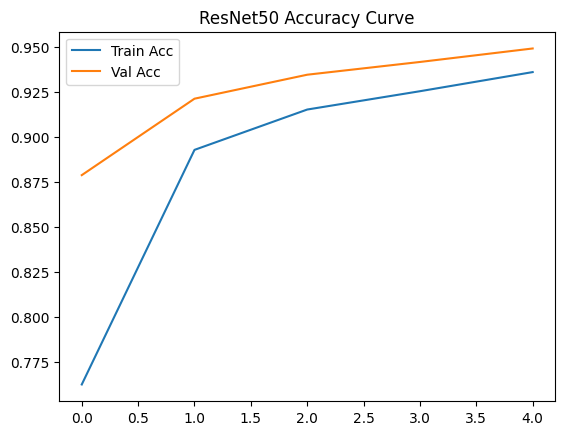

In [ ]:
plt.plot(train_accs, label="Train Acc")
plt.plot(val_accs, label="Val Acc")
plt.legend()
plt.title("ResNet50 Accuracy Curve")
plt.show()

#EfficentNEtB0

In [ ]:
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights

model = efficientnet_b0(weights=EfficientNet_B0_Weights.DEFAULT)

for param in model.parameters():
    param.requires_grad = False

num_features = model.classifier[1].in_features
model.classifier[1] = nn.Linear(num_features, len(class_names))

model = model.to(device)

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 54.6MB/s]


In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.classifier[1].parameters(), lr=0.001)

In [ ]:
model, train_losses, val_losses, train_accs, val_accs = train_model(
    model, train_loader, val_loader, criterion, optimizer, epochs=5
)


Epoch 1/5
Train Loss: 0.8016 | Train Acc: 0.7874
Val Loss: 0.4431 | Val Acc: 0.8834

Epoch 2/5
Train Loss: 0.4056 | Train Acc: 0.8850
Val Loss: 0.3497 | Val Acc: 0.8951

Epoch 3/5
Train Loss: 0.3377 | Train Acc: 0.8979
Val Loss: 0.2903 | Val Acc: 0.9172

Epoch 4/5
Train Loss: 0.3028 | Train Acc: 0.9066
Val Loss: 0.2664 | Val Acc: 0.9188

Epoch 5/5
Train Loss: 0.2836 | Train Acc: 0.9134
Val Loss: 0.2397 | Val Acc: 0.9313


In [ ]:
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

acc = accuracy_score(all_labels, all_preds)
f1 = f1_score(all_labels, all_preds, average='weighted')

print("Test Accuracy:", acc)
print("Weighted F1:", f1)

Test Accuracy: 0.9110556940980881
Weighted F1: 0.9111916050753407


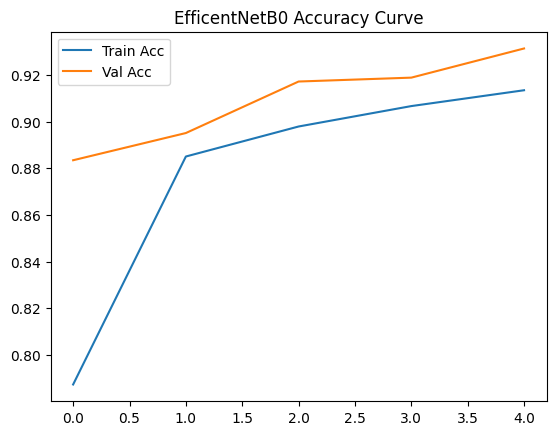

In [ ]:
plt.plot(train_accs, label="Train Acc")
plt.plot(val_accs, label="Val Acc")
plt.legend()
plt.title("EfficentNetB0 Accuracy Curve")
plt.show()

#Transformer- DeiT-Tiny

In [ ]:
!pip install timm

In [ ]:
import timm

model = timm.create_model('deit_tiny_patch16_224', pretrained=True, num_classes=len(class_names))
model = model.to(device)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/22.9M [00:00<?, ?B/s]

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

In [ ]:
model, train_losses, val_losses, train_accs, val_accs = train_model(
    model, train_loader, val_loader, criterion, optimizer, epochs=5
)


Epoch 1/5


KeyboardInterrupt: 

In [ ]:
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

acc = accuracy_score(all_labels, all_preds)
f1 = f1_score(all_labels, all_preds, average='weighted')

print("Test Accuracy:", acc)
print("Weighted F1:", f1)

Test Accuracy: 0.9733998337489609
Weighted F1: 0.9733607315898146


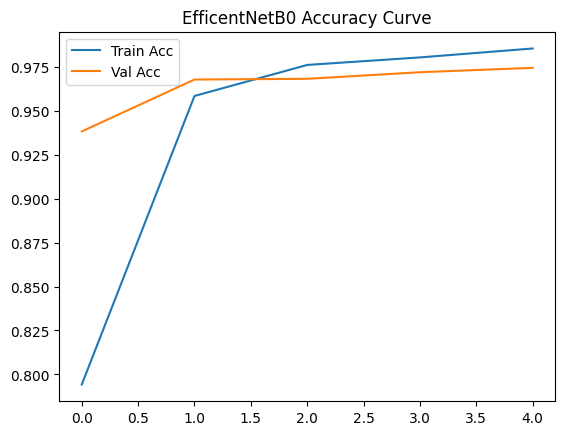

In [ ]:
plt.plot(train_accs, label="Train Acc")
plt.plot(val_accs, label="Val Acc")
plt.legend()
plt.title("EfficentNetB0 Accuracy Curve")
plt.show()

#MobileViT

In [ ]:
model = timm.create_model('mobilevit_s', pretrained=True, num_classes=len(class_names))
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

model.safetensors:   0%|          | 0.00/22.4M [00:00<?, ?B/s]

In [ ]:
start_time = time.time()

model, train_losses, val_losses, train_accs, val_accs = train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    epochs=5
)

print("Training Time:", time.time() - start_time)


Epoch 1/5


In [ ]:
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

acc = accuracy_score(all_labels, all_preds)
f1 = f1_score(all_labels, all_preds, average='weighted')

print("Test Accuracy:", acc)
print("Weighted F1:", f1)

RuntimeError: Input type (torch.cuda.FloatTensor) and weight type (torch.FloatTensor) should be the same

In [ ]:
plt.plot(train_accs, label="Train Acc")
plt.plot(val_accs, label="Val Acc")
plt.legend()
plt.title("MobileviT Accuracy Curve")
plt.show()